# **[과제]** 로이터 뉴스를 분류할 수 있는 신경망 생성
  
- 로이터 뉴스 데이터는 11,258개의 뉴스 기사를 46개의 뉴스 카테고리로 분류하여 제공함.
- 아래의 baseline 모델 구조와 동일하게 모델의 구조를 정의하고, model.summary() 출력


### **조건** :
1. Hyper parameter는 고정
2. Dense layer 안의 파라미터를 조정하여 표기되어있는 baseline 구조와 동일하게 모델 구축
3. Dropout은 0.5로 설정
4. 첫번째 Activation func는 'relu', 두번째 Activation func는 'softmax'로 설정

\
 예시) layer추가
```python
# 입력 Dense layer 함수 예시 (두번째 Dense layer부터는 output channel만 설정해도 무관)
Dense(output_channel, input_shape = input_shape)
# Activation func layer 함수 예시
Activation('activation func')
```



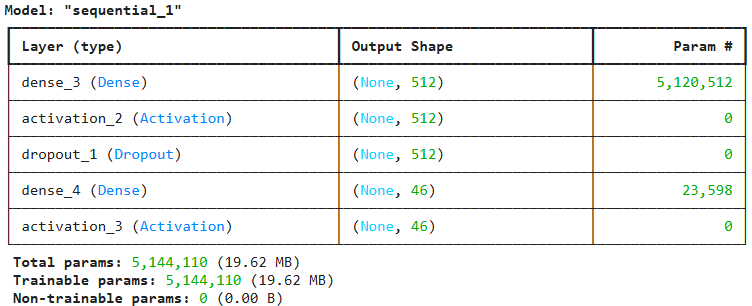




In [45]:
print("최대영", "2353881")


최대영 2353881


In [46]:
#from google.colab import auth

#auth.authenticate_user()
#!gcloud config get-value account

In [47]:
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
import numpy as np

In [48]:
# gpu 확인
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


##데이터 불러오기

In [49]:
from tensorflow.keras.datasets import reuters

(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words = None, test_split=0.3)

In [50]:
word_index = reuters.get_word_index(path="reuters_word_index.json")

In [51]:
# 힌트 : 로이터 뉴스의 class 개수는 46개
# num_classes = max(?) + 1
''' 코드를 작성해 주세요 '''
num_classes = np.max(y_train) + 1

In [52]:
print('# of Training Samples: {}'.format(len(x_train)))
print('# of Test Samples: {}'.format(len(x_test)))
print('# of Classes: {}'.format(num_classes))

# of Training Samples: 7859
# of Test Samples: 3369
# of Classes: 46


In [53]:
index_to_word = {}
for k, v in word_index.items():
  index_to_word[v] = k

In [54]:
print(' '.join([index_to_word[x] for x in x_train[0]]))
print(y_train[0])

the wattie nondiscriminatory mln loss for plc said at only ended said commonwealth could 1 traders now april 0 a after said from 1985 and from foreign 000 april 0 prices its account year a but in this mln home an states earlier and rise and revs vs 000 its 16 vs 000 a but 3 psbr oils several and shareholders and dividend vs 000 its all 4 vs 000 1 mln agreed largely april 0 are 2 states will billion total and against 000 pct dlrs
3


## 단어 시퀀스를 매트릭스로 생성

In [55]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow import keras

max_words = 10000

tokenizer = Tokenizer(num_words=max_words)
# x_train, x_test의 단어 시퀀스를 매트릭스로 생성
# 힌트 : x_train = tokenizer.sequences_to_matrix(???, mode='binary)
''' 코드를 입력해 주세요.'''
x_train = tokenizer.sequences_to_matrix(x_train, mode='binary')
x_test = tokenizer.sequences_to_matrix(x_test, mode='binary')

In [56]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [57]:
print(x_train[0])
print(len(x_train))

print(y_train[0])
print(len(y_train))

[0. 1. 0. ... 0. 0. 0.]
7859
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
7859


##모델 생성

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Input

model = Sequential([

        Dense(512, input_shape=(10000,)),
    Activation('relu'),

    # 드롭아웃 설정 (과제 조건: 0.5)
    Dropout(0.5),

    # 출력 레이어: 46개 카테고리 분류
    Dense(46),
    Activation('softmax')

    ])

model.compile(loss = 'categorical_crossentropy',
              optimizer = 'adam',
              metrics = ['accuracy'])

In [59]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │     5,120,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 46)             │        23,598 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 46)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,144,110 (19.62 MB)

 Trainable params: 5,144,110 (19.62 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
batch_size = 32
epochs = 3

In [61]:
''' 코드를 작성해 주세요. '''
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_split=0.1
)

Epoch 1/3
222/222 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.7119 - loss: 1.3456 - val_accuracy: 0.8104 - val_loss: 0.8441
Epoch 2/3
222/222 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.8853 - loss: 0.5171 - val_accuracy: 0.8308 - val_loss: 0.7619
Epoch 3/3
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.9384 - loss: 0.2740 - val_accuracy: 0.8168 - val_loss: 0.8098


In [62]:
''' 코드를 작성해 주세요. '''
score = model.evaluate(x_test , y_test , batch_size=batch_size, verbose=1)

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8118 - loss: 0.8711


In [63]:
print('Test loss: ', round(score[0],3))
print('Test accuracy:', round(score[1],3))

Test loss:  0.871
Test accuracy: 0.812
